In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import stan
import seaborn as sns
from pathlib import Path
from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde

import nest_asyncio
nest_asyncio.apply()

import logging
logging.getLogger().setLevel(logging.ERROR)

/home/vivek/Documents/.pystan/lib/python3.12/site-packages/stan/plugins.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
## Output folder for figures
out_dir = Path("output")
out_dir.mkdir(exist_ok=True)

In [3]:
## Load PCF curves and peak table
pcf_all = pd.read_csv('processed_data/pcf_curve_ALL.csv')
peaks = pd.read_csv('processed_data/pcf_peak_table_ALL.csv')

pcf_all['date'] = pd.to_datetime(pcf_all['date'])
peaks['date'] = pd.to_datetime(peaks['date'])

pcf_all.head()

,r,g,lek_id,data_label,date,n_points,r_max_used,ref_median_nn
0,5.224499,0.048594,TalChhapar_TC,12OCT,2012-10-01,162,65.718693,16.429673
1,5.499472,0.057370,TalChhapar_TC,12OCT,2012-10-01,162,65.718693,16.429673
2,5.774446,0.067809,TalChhapar_TC,12OCT,2012-10-01,162,65.718693,16.429673
3,6.049419,0.078164,TalChhapar_TC,12OCT,2012-10-01,162,65.718693,16.429673
4,6.324393,0.088378,TalChhapar_TC,12OCT,2012-10-01,162,65.718693,16.429673


In [4]:
## Create consistent integer encodings for sites
site_lookup = {lek: i+1 for i,lek in enumerate(sorted(pcf_all['lek_id'].unique()))}
unique_dates = sorted(pcf_all['date'].unique())

pcf_all['site_id'] = pcf_all['lek_id'].map(site_lookup)
peaks['site_id'] = peaks['lek_id'].map(site_lookup)

In [5]:
## Isolate a row for each PCF curve to count peaks
cols = ['lek_id', 'site_id', 'date', 'n_points']
curves_base = pcf_all[cols].drop_duplicates().sort_values(['lek_id', 'date']).reset_index(drop=True)

In [6]:
## For each curve (lek × date), get the peak-count category; curves with no detected peaks become 0
peaks_count = peaks.groupby(['lek_id', 'date'], as_index=False)['n_peaks'].max().rename(columns={'n_peaks': 'n_peaks'})
n_peaks_df = curves_base.merge(peaks_count, on=['lek_id', 'date'], how='left').assign(n_peaks=lambda d: d['n_peaks'].fillna(0).astype(int))

In [7]:
## Factor ordering + labels
lek_order = ['TalChhapar_TC', 'Velavadar_LEK1', 'Velavadar_LEK2']
lek_labels = {'TalChhapar_TC': 'Tal Chhapar', 'Velavadar_LEK1': 'Velavadar Lek 1','Velavadar_LEK2': 'Velavadar Lek 2'}

n_peaks_df['lek_id'] = (pd.Categorical(n_peaks_df['lek_id'],categories=lek_order,ordered=True).rename_categories(lek_labels))

## Map site ID to lek labels
site_to_lek = n_peaks_df[['site_id', 'lek_id']].drop_duplicates().sort_values('site_id')
site_to_lek = dict(zip(site_to_lek['site_id'].astype(int), site_to_lek['lek_id']))

In [8]:
## Colour palettes
fill_cols = {'Tal Chhapar': '#B5542D', 'Velavadar Lek 1': '#1F6F8B', 'Velavadar Lek 2': '#3FA7A3'}
point_cols = {'Tal Chhapar': '#D97A52', 'Velavadar Lek 1': '#15556B', 'Velavadar Lek 2': '#2B7E7B'}

lek_labels_ordered = n_peaks_df['lek_id'].cat.categories.tolist()

In [9]:
## Model the number of peaks for each lek
## Ordered logistic model: latent "structure" score per site and cutpoints define peak count categories
n_peaks_mod = """
data {
    int<lower=1> n_points;
    int<lower=1> n_sites;
    int<lower=2> max_peaks;

    array[n_points] int<lower=1,upper=n_sites> site_id;
    array[n_points] int<lower=1,upper=max_peaks> y;
    
    vector[n_points] n_points_z;
}

parameters {
    real alpha;
    vector[n_sites] site_eff_raw;
    ordered[max_peaks-1] c;
    
    real beta_npoints;
}

transformed parameters {
    vector[n_sites] site_eff;
    site_eff = site_eff_raw - mean(site_eff_raw);
}

model {
    alpha ~ normal(0, 1);
    site_eff_raw ~ normal(0, 1);
    c ~ normal(0, 2);
    beta_npoints ~ normal(0, 1);

    for (n in 1:n_points) {
        real eta = alpha + site_eff[site_id[n]] + beta_npoints*n_points_z[n];
        y[n] ~ ordered_logistic(eta, c);
    }
}

generated quantities {
    real diff_T_V1 = site_eff[1] - site_eff[2];
    real diff_V1_V2 = site_eff[2] - site_eff[3];
    real diff_T_V2 = site_eff[1] - site_eff[3];

    array[n_sites] vector[max_peaks] p_site;

    for (s in 1:n_sites) {
        real eta = alpha + site_eff[s];

        // cumulative probs: P(Y <= k)
        vector[max_peaks - 1] F;
        for (k in 1:(max_peaks - 1)) {
            F[k] = inv_logit(c[k] - eta);
        }

        // category probs from cumulative probs
        p_site[s][1] = F[1];
        for (k in 2:(max_peaks - 1)) {
            p_site[s][k] = F[k] - F[k - 1];
        }
        p_site[s][max_peaks] = 1 - F[max_peaks - 1];
    }
}
"""

In [10]:
log_n = np.log(n_peaks_df['n_points'].astype(float).to_numpy())
n_points_z = (log_n - log_n.mean()) / log_n.std(ddof=0)

data_peaks = {
    'n_points': len(n_peaks_df),
    'n_sites': int(n_peaks_df['site_id'].nunique()),
    'max_peaks': 4,
    'site_id': n_peaks_df['site_id'].astype(int).to_numpy(),
    'y': n_peaks_df['n_peaks'].astype(int).to_numpy() + 1,
    'n_points_z': n_points_z.astype(float)
}

posterior = stan.build(n_peaks_mod, data=data_peaks)
fit = posterior.sample(num_chains=4, num_warmup=1000, num_samples=1000)

Building: found in cache, done.
Sampling:   0%
Sampling:   5% (400/8000)
Sampling:  30% (2400/8000)
Sampling:  55% (4400/8000)
Sampling:  80% (6400/8000)
Sampling: 100% (8000/8000)
Sampling: 100% (8000/8000), done.
Messages received during sampling:
  Gradient evaluation took 8.8e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.88 seconds.
  Adjust your expectations accordingly!
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 2 is -10.9823, but should be greater than the previous element, -10.9823 (in '/tmp/httpstan_d_xfpnbw/model_72dko6cf.stan', line 34, column 8 to column 40)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned o

In [11]:
## Posterior distributions of latent structure on the leks
site_eff = fit['site_eff']
tal = site_eff[0, :]
vel1 = site_eff[1, :]
vel2 = site_eff[2, :]

## Difference in latent structure between Tal Chhapar and the two Velavadar leks
delta1 = tal - vel1
delta2 = tal - vel2

In [12]:
## Probability of the Tal Chhapar lek having more structure
pr_v1 = (delta1 > 0).mean()
pr_v2 = (delta2 > 0).mean()

## Median + CI of difference in structure between the two locations
med_diff1 = np.median(delta1)
ci_diff1 = np.quantile(delta1, [0.025, 0.975])
med_diff2 = np.median(delta2)
ci_diff2 = np.quantile(delta2, [0.025, 0.975])

## Odds ratio of the median difference in structure
or_med1 = np.exp(med_diff1)
or_med2 = np.exp(med_diff2)

print(f'The probability of Tal Chhapar having more latent structure than the Velavadar leks is {pr_v1} and  {pr_v2} respectively')
print(f'The probability of curves having 2 or more peaks for Tal Chhapar and Velavadar leks is {fit['p_site'].mean(2)[:,2:].sum(1)} respectively')
print(f'The median difference (and corresponding confidence interval) between latent structure in Tal Chhapar and the Velavadar leks are {med_diff1}, {ci_diff1}, {med_diff2} and {ci_diff2}')
print(f'The odds ratio between latent structure in Tal Chhapar and the Velavadar leks are {or_med1} and {or_med2}')

The probability of Tal Chhapar having more latent structure than the Velavadar leks is 0.88675 and  0.973 respectively
The probability of curves having 2 or more peaks for Tal Chhapar and Velavadar leks is [0.63075909 0.40614172 0.29631065] respectively
The median difference (and corresponding confidence interval) between latent structure in Tal Chhapar and the Velavadar leks are 0.9974848206079443, [-0.61280929  2.63276046], 1.5253248139952524 and [-0.01925466  3.06837251]
The odds ratio between latent structure in Tal Chhapar and the Velavadar leks are 2.711453452916792 and 4.596636378677757


In [13]:
## Empirical probability of each peak count category per lek (for plotting against posterior)
peak_categories = np.sort(n_peaks_df['n_peaks'].unique())

peaks_counts = n_peaks_df[['lek_id', 'date', 'n_peaks']].drop_duplicates().copy()
peak_proportions = peaks_counts.assign(n_peaks=lambda d: d['n_peaks'].astype(int)).groupby(['lek_id', 'n_peaks'], observed=False).size().rename('count').reset_index()
peak_proportions['prop'] = peak_proportions.groupby('lek_id', observed=False)['count'].transform(lambda x: x / x.sum())

In [14]:
n_sites_post, k_post, n_draws = fit['p_site'].shape
assert k_post == len(n_peaks_df['n_peaks'].unique()), f'p_site has {k_post} categories, expected {max_peaks}'

## Summarize posterior p_site per site × category
post_rows = []
for s in range(1, n_sites_post+1):
    for k in range(1, k_post+1):
        draws = fit['p_site'][s-1, k-1, :]
        post_rows.append({
            'site_id': s, 'lek_id': site_to_lek.get(s), 'n_peaks': k-1, 
            'mean': float(np.mean(draws)), 'lower': float(np.quantile(draws, 0.025)), 'upper': float(np.quantile(draws, 0.975))})
        
post = pd.DataFrame(post_rows)

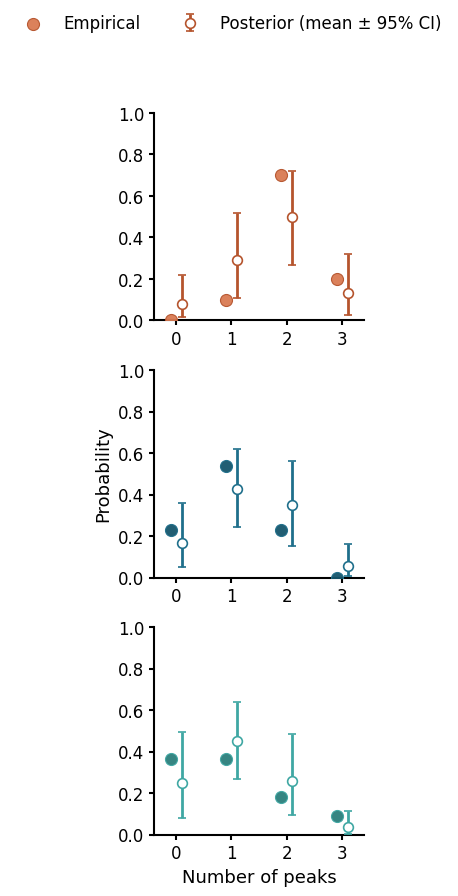

In [15]:
## Plot empirical category probabilities against posterior (mean ± 95% CI)
fig, axes = plt.subplots(3, 1, figsize=(3, 9), sharey=True)

x_offset = 0.1  # small dodge so empirical and posterior don't overlap

for ax, lek in zip(axes, lek_labels_ordered):
    empirical_data = peak_proportions[peak_proportions['lek_id'] == lek].sort_values('n_peaks')
    model_posteriors = post[post['lek_id'] == lek].sort_values('n_peaks')

    col_fill = fill_cols[str(lek)]
    col_point = point_cols[str(lek)]

    # Empirical proportions (filled markers)
    ax.scatter(empirical_data['n_peaks'] - x_offset, empirical_data['prop'], s=75,
               facecolor=col_point, edgecolor=col_fill,
               linewidth=0.8, alpha=0.95, zorder=4,
               label="Empirical" if ax is axes[0] else None)

    # Posterior mean + 95% CI (hollow markers + error bars)
    ax.errorbar(model_posteriors['n_peaks'] + x_offset, model_posteriors['mean'],
                yerr=[model_posteriors['mean'] - model_posteriors['lower'], model_posteriors['upper'] - model_posteriors['mean']],
                fmt='o', markersize=7, mfc='white', mec=col_fill, mew=1.2,
                color=col_fill, ecolor=col_fill, elinewidth=2, capsize=3, zorder=3,
                label="Posterior (mean ± 95% CI)" if ax is axes[0] else None)

    ax.set_xticks(peak_categories)
    ax.set_xlim(-0.4, peak_categories.max() + 0.4)
    ax.set_ylim(0, 1)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.tick_params(axis='both', which='major', labelsize=12, width=1.5)

axes[2].set_xlabel('Number of peaks', fontsize=13)
axes[1].set_ylabel('Probability', fontsize=13)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False, fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.savefig(out_dir/'npeaks_structure.png', dpi=300, bbox_inches='tight')

In [16]:
## Assign a unique curve ID for each lek × date
curves_base['curve_id'] = np.arange(1, len(curves_base) + 1, dtype=int)
peaks_only = peaks.dropna(subset=['peak_curvature']).copy()

## Attach curve IDs to each peak row
curvature_df = peaks_only.merge(curves_base[['lek_id', 'date', 'site_id', 'n_points', 'curve_id']], 
                                on=['lek_id', 'date', 'site_id', 'n_points'], how='left', validate='many_to_one')
curvature_df['curve_id'] = pd.factorize(curvature_df['curve_id'])[0] + 1

In [17]:
## Define peak order within each curve
curvature_df = curvature_df.sort_values(['lek_id', 'date', 'r_peak']).reset_index(drop=True)
curvature_df['peak_num'] = curvature_df.groupby(['lek_id', 'date'], observed=False).cumcount() + 1

## Log transform curvature to construct a log-normal model and center peak number
curvature_df['log_curvature'] = np.log(curvature_df['peak_curvature'].astype(float))
curvature_df['peak_num_z'] = curvature_df['peak_num'] - curvature_df['peak_num'].mean()

curvature_df = curvature_df[['lek_id', 'site_id', 'date', 'curve_id', 'n_points', 'peak_num', 'peak_num_z', 
                             'r_peak', 's_peak', 'peak_prominence', 'peak_curvature', 'log_curvature']]
curvature_df.head()

,lek_id,site_id,date,curve_id,n_points,peak_num,peak_num_z,r_peak,s_peak,peak_prominence,peak_curvature,log_curvature
0,TalChhapar_TC,1,2012-10-01,1,162,1,-0.466667,23.372757,1.471804,0.288691,3.674547,1.301430
1,TalChhapar_TC,1,2012-10-01,1,162,2,0.533333,41.521015,2.614617,0.051697,1.322597,0.279597
2,TalChhapar_TC,1,2014-02-01,2,193,1,-0.466667,22.822810,1.521247,0.111816,2.960623,1.085400
3,TalChhapar_TC,1,2015-11-01,3,127,1,-0.466667,24.747625,1.530353,0.177206,1.585560,0.460938
4,TalChhapar_TC,1,2015-11-01,3,127,2,0.533333,45.370646,2.805647,0.048893,1.394720,0.332693


In [18]:
curvature_mod = """
data {
  int<lower=1> n_points;
  int<lower=1> n_sites;
  int<lower=1> n_curves;

  array[n_points] int<lower=1, upper=n_sites> site_id;
  array[n_points] int<lower=1, upper=n_curves> curve_id;

  vector[n_points] peak_num_z;
  vector[n_points] log_curvature;
}

parameters {
  real alpha;

  vector[n_sites] site_eff_raw;
  real<lower=0> sigma_site;

  vector[n_curves] curve_eff_raw;
  real<lower=0> sigma_curve;

  real beta_peaknum;

  real<lower=0> sigma;
}

transformed parameters {
  vector[n_sites] site_eff = site_eff_raw * sigma_site;
  vector[n_curves] curve_eff = curve_eff_raw * sigma_curve;
}

model {
  // priors
  alpha ~ normal(0, 3);

  site_eff_raw ~ normal(0, 1);
  sigma_site ~ normal(0, 1);

  curve_eff_raw ~ normal(0, 1);
  sigma_curve ~ normal(0, 1);

  beta_peaknum ~ normal(0, 1);

  sigma ~ normal(0, 1);

  // likelihood
  for (n in 1:n_points) {
    real mu = alpha + site_eff[site_id[n]] + curve_eff[curve_id[n]] + beta_peaknum * peak_num_z[n];
    log_curvature[n] ~ normal(mu, sigma);
  }
}

generated quantities {
  // site contrasts on log scale
  real diff_T_V1 = site_eff[1] - site_eff[2];
  real diff_T_V2 = site_eff[1] - site_eff[3];
  real diff_V1_V2 = site_eff[2] - site_eff[3];

  // geometric mean ratios on original curvature scale
  real gmr_T_V1 = exp(diff_T_V1);
  real gmr_T_V2 = exp(diff_T_V2);
  real gmr_V1_V2 = exp(diff_V1_V2);
}
"""

In [19]:
data_curvature = {
    'n_points': len(curvature_df),
    'n_sites': int(curvature_df['site_id'].nunique()),
    'n_curves': int(curvature_df['curve_id'].nunique()),
    'site_id': curvature_df['site_id'].astype(int).to_numpy(),
    'curve_id': curvature_df['curve_id'].astype(int).to_numpy(),
    'peak_num_z': curvature_df['peak_num_z'].astype(float).to_numpy(),
    'log_curvature': curvature_df['log_curvature'].astype(float).to_numpy(),
}

posterior = stan.build(curvature_mod, data=data_curvature)
fit = posterior.sample(num_chains=4, num_warmup=1000, num_samples=1000)

Building: found in cache, done.
Sampling:   0%
Sampling:  10% (800/8000)
Sampling:  35% (2800/8000)
Sampling:  60% (4800/8000)
Sampling:  85% (6800/8000)
Sampling: 100% (8000/8000)
Sampling: 100% (8000/8000), done.
Messages received during sampling:
  Gradient evaluation took 6.5e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.65 seconds.
  Adjust your expectations accordingly!
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: normal_lpdf: Location parameter is inf, but must be finite! (in '/tmp/httpstan_dxunt5e2/model_ldbdvcsr.stan', line 50, column 4 to column 41)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Gradient evaluation took 5e-05 seconds
  1000 transitions using 10 lea

In [30]:
def plot_split_hist_kde(ax, samples, color_left, color_right, bins=60, title='', xlim=None, ylim=None, annotate=True):
    '''
    Plot a density histogram + KDE, with colors split at x=1.
    Left of 1 uses color_left, right of 1 uses color_right.
    xlim/ylim can be provided to enforce shared axes across subplots.
    '''
    samples = np.asarray(samples)
    samples = samples[np.isfinite(samples)]
    
    x_min,x_max = xlim

    # Plot histogram density
    counts, edges = np.histogram(samples, bins=bins, range=(x_min, x_max), density=True)
    centers = 0.5 * (edges[:-1] + edges[1:])
    widths = np.diff(edges)

    left_mask = centers <= 1
    right_mask = centers > 1

    ax.bar(centers[left_mask], counts[left_mask], width=widths[left_mask], align='center', alpha=0.3, edgecolor='none', color=color_left)
    ax.bar(centers[right_mask], counts[right_mask], width=widths[right_mask], align='center', alpha=0.3, edgecolor='none', color=color_right)

    # Add KDE to plot
    xs = np.linspace(x_min, x_max, 600)
    kde = gaussian_kde(samples)
    ys = kde(xs)

    left = xs <= 1
    right = xs >= 1

    ax.plot(xs[left], ys[left], linewidth=3, color=color_left)
    ax.plot(xs[right], ys[right], linewidth=3, color=color_right)

    # Parity line
    ax.axvline(1, linestyle='dashed', linewidth=1.5, color='black', alpha=0.85)

    ax.set_title(title, fontsize=13)
    ax.set_xlim(x_min, x_max)

    if ylim is not None:
        ax.set_ylim(0, ylim)
    else:
        ax.set_ylim(bottom=0)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.tick_params(axis='both', labelsize=12, width=1.5)
    ax.margins(x=0)

    return xs, ys

In [31]:
## Pull posterior draws
posterior_samples = np.concatenate([fit['gmr_T_V1'][0, :], fit['gmr_T_V2'][0, :], fit['gmr_V1_V2'][0, :]])
posterior_samples = posterior_samples[np.isfinite(posterior_samples)]

## Share x-range across panels
lo, hi = np.quantile(posterior_samples, [0.005, 0.995])
pad = 0.1 * (hi - lo)
xlim = (max(0, lo - pad), hi + pad)

## Pre-compute a shared ymax by evaluating KDEs on the same x-grid
xs = np.linspace(xlim[0], xlim[1], 600)
ymax = 0
for sample in [fit['gmr_T_V1'][0, :], fit['gmr_T_V2'][0, :], fit['gmr_V1_V2'][0, :]]:
    sample = np.asarray(sample)
    sample = sample[np.isfinite(sample)]
    ys = gaussian_kde(sample)(xs)
    ymax = max(ymax, ys.max())

ylim = ymax * 1.2

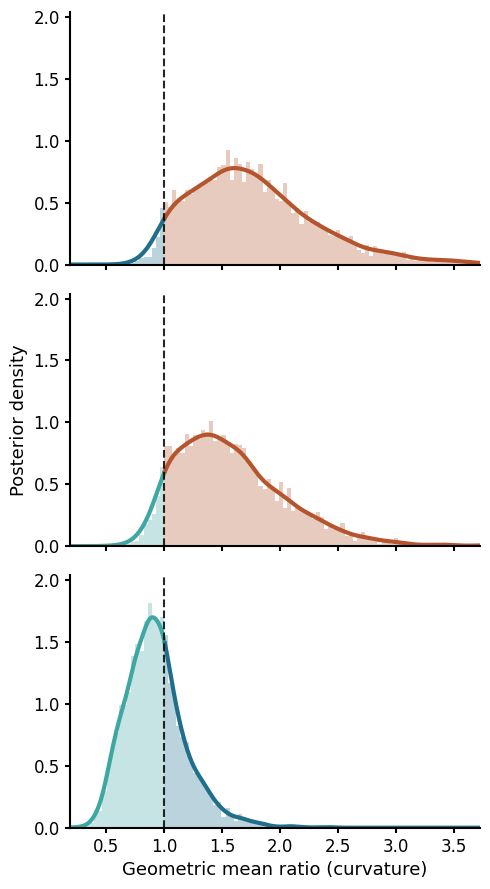

In [32]:
## Plot the GMR of the curvatures
fig, axes = plt.subplots(3, 1, figsize=(5, 9), sharex=True)

plot_split_hist_kde(axes[0], fit['gmr_T_V1'][0, :], color_left=fill_cols['Velavadar Lek 1'], color_right=fill_cols['Tal Chhapar'], bins=100, xlim=xlim, ylim=ylim)
plot_split_hist_kde(axes[1], fit['gmr_T_V2'][0, :], color_left=fill_cols['Velavadar Lek 2'], color_right=fill_cols['Tal Chhapar'], bins=100, xlim=xlim, ylim=ylim)
plot_split_hist_kde(axes[2], fit['gmr_V1_V2'][0, :], color_left=fill_cols['Velavadar Lek 2'], color_right=fill_cols['Velavadar Lek 1'], bins=100, xlim=xlim, ylim=ylim)

axes[1].set_ylabel("Posterior density", fontsize=13)
axes[2].set_xlabel("Geometric mean ratio (curvature)", fontsize=13)

axes[0].tick_params(labelbottom=False)
axes[1].tick_params(labelbottom=False)

plt.tight_layout()
plt.savefig(out_dir/'gmr_peak_curvatures.png', dpi=300, bbox_inches='tight')